Inisialisasi dan Import Library

In [0]:
import mlflow
from mlflow.models import infer_signature
from pyspark.sql.functions import col
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.metrics import (
    accuracy_score, 
    roc_auc_score, 
    classification_report, 
    ConfusionMatrixDisplay, 
    RocCurveDisplay
)

Konfigurasi MLflow Autologging

In [0]:
mlflow.autolog(
    log_models=False, 
    log_model_signatures=False, 
    exclusive=True
)

2025/11/15 19:39:46 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.
2025/11/15 19:39:46 INFO mlflow.tracking.fluent: Autologging successfully enabled for statsmodels.


MLflow Autologging (untuk parameter dan metrik) diaktifkan.


Load Data dari Silver Layer

In [0]:
# Muat data bersih dari tabel DLT Silver Layer
try:
    silver_df = spark.table("workspace.churn_analytics.churn_silver") \
                     .drop("customerID") # customerID dihapus di sini
except Exception as e:
    print("Error: Pastikan nama tabel 'workspace.churn_analytics.churn_silver' sudah benar.")
    raise e

# Tampilkan skema untuk verifikasi
print("Skema data Silver Layer (setelah customerID dihapus):")
silver_df.printSchema()

# Ubah ke Pandas DataFrame untuk Scikit-Learn
df = silver_df.toPandas()
print(f"\nBerhasil memuat {len(df)} baris data ke Pandas DataFrame.")

Skema data Silver Layer (setelah customerID dihapus):
root
 |-- gender: string (nullable = true)
 |-- SeniorCitizen: integer (nullable = true)
 |-- Partner: string (nullable = true)
 |-- Dependents: string (nullable = true)
 |-- tenure: integer (nullable = true)
 |-- PhoneService: string (nullable = true)
 |-- MultipleLines: string (nullable = true)
 |-- InternetService: string (nullable = true)
 |-- OnlineSecurity: string (nullable = true)
 |-- OnlineBackup: string (nullable = true)
 |-- DeviceProtection: string (nullable = true)
 |-- TechSupport: string (nullable = true)
 |-- StreamingTV: string (nullable = true)
 |-- StreamingMovies: string (nullable = true)
 |-- Contract: string (nullable = true)
 |-- PaperlessBilling: string (nullable = true)
 |-- PaymentMethod: string (nullable = true)
 |-- MonthlyCharges: double (nullable = true)
 |-- TotalCharges: double (nullable = true)
 |-- Churn: integer (nullable = true)
 |-- _rescued_data: string (nullable = true)


Berhasil memuat 14086 

In [0]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14086 entries, 0 to 14085
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            14086 non-null  object 
 1   SeniorCitizen     14086 non-null  int32  
 2   Partner           14086 non-null  object 
 3   Dependents        14086 non-null  object 
 4   tenure            14086 non-null  int32  
 5   PhoneService      14086 non-null  object 
 6   MultipleLines     14086 non-null  object 
 7   InternetService   14086 non-null  object 
 8   OnlineSecurity    14086 non-null  object 
 9   OnlineBackup      14086 non-null  object 
 10  DeviceProtection  14086 non-null  object 
 11  TechSupport       14086 non-null  object 
 12  StreamingTV       14086 non-null  object 
 13  StreamingMovies   14086 non-null  object 
 14  Contract          14086 non-null  object 
 15  PaperlessBilling  14086 non-null  object 
 16  PaymentMethod     14086 non-null  object

Diagnostik Data (Null & Duplikat)

In [0]:
print("--- 1. Pengecekan Nilai Duplikat (Baris Keseluruhan) ---")
# Cek duplikat baris
duplicate_rows = df.duplicated().sum()
print(f"Jumlah baris duplikat: {duplicate_rows}")

# Hapus duplikat jika ada (membersihkan data dari Fase 3)
if duplicate_rows > 0:
    df = df.drop_duplicates(keep='first')
    print(f"Baris duplikat telah dihapus. Sisa data: {len(df)} baris.")

print("\n--- 2. Pengecekan Nilai Null ---")
null_counts = df.isnull().sum()
null_cols = null_counts[null_counts > 0]

if null_cols.empty:
    print("Tidak ada nilai null (NaN) di dalam data.")
else:
    print("Ditemukan nilai null (NaN) pada kolom berikut:")
    print(null_cols)
    
    # Cek jika ada kolom yang 100% null (seperti _rescued_data)
    cols_to_drop = null_cols[null_cols == len(df)].index.tolist()
    if cols_to_drop:
        print(f"\nPERINGATAN: Kolom berikut 100% null dan akan dihapus: {cols_to_drop}")
        df = df.drop(columns=cols_to_drop)

--- 1. Pengecekan Nilai Duplikat (Baris Keseluruhan) ---
Jumlah baris duplikat: 7065
Baris duplikat telah dihapus. Sisa data: 7021 baris.

--- 2. Pengecekan Nilai Null ---
Ditemukan nilai null (NaN) pada kolom berikut:
_rescued_data    7021
dtype: int64

PERINGATAN: Kolom berikut 100% null dan akan dihapus: ['_rescued_data']


EDA

Membuat Heatmap Korelasi Numerik...


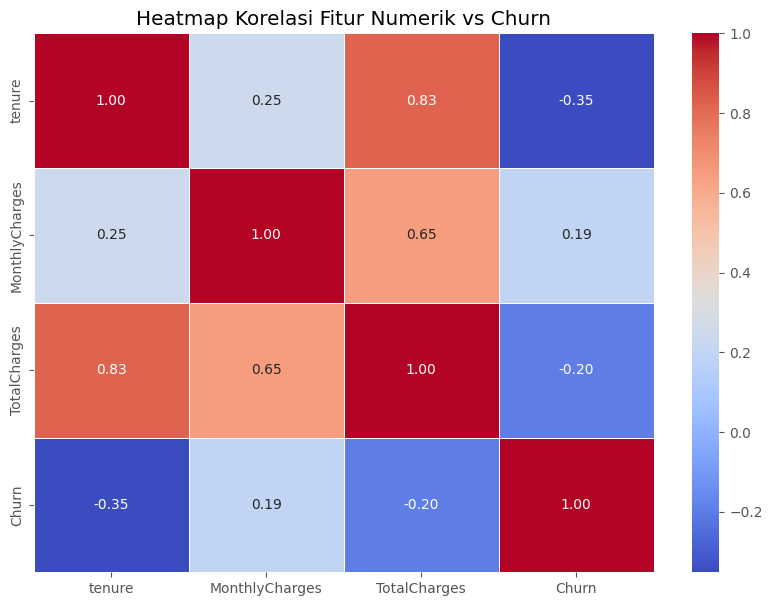

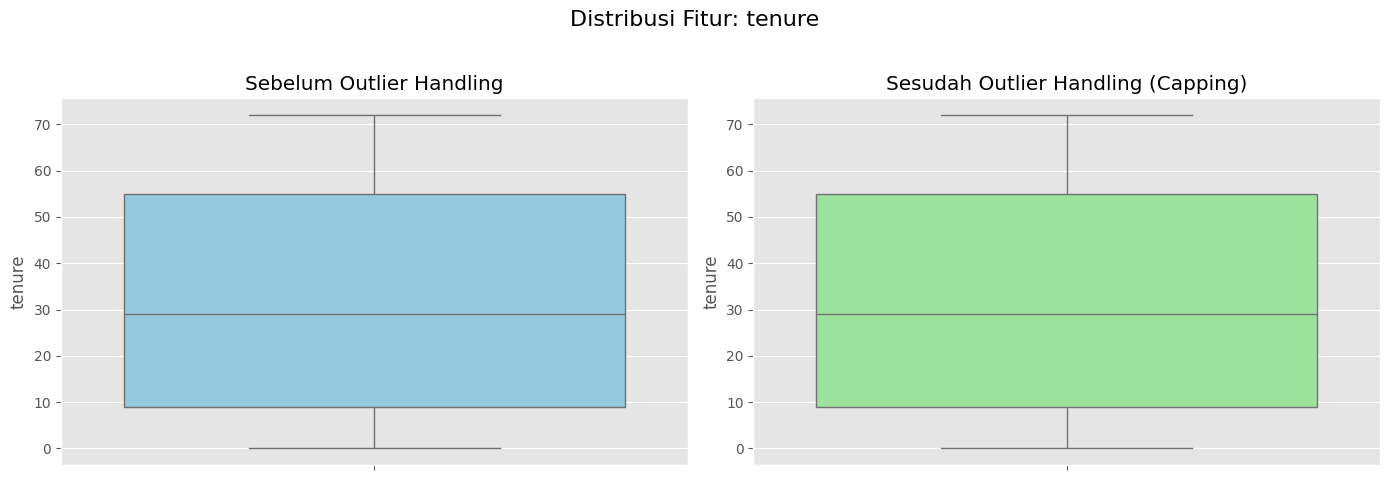

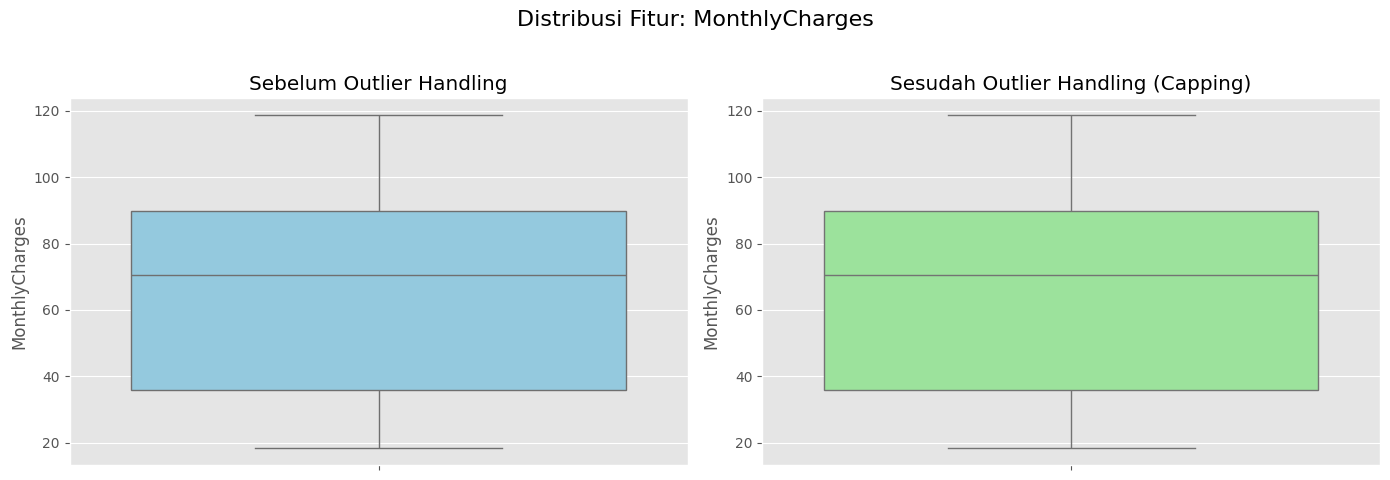

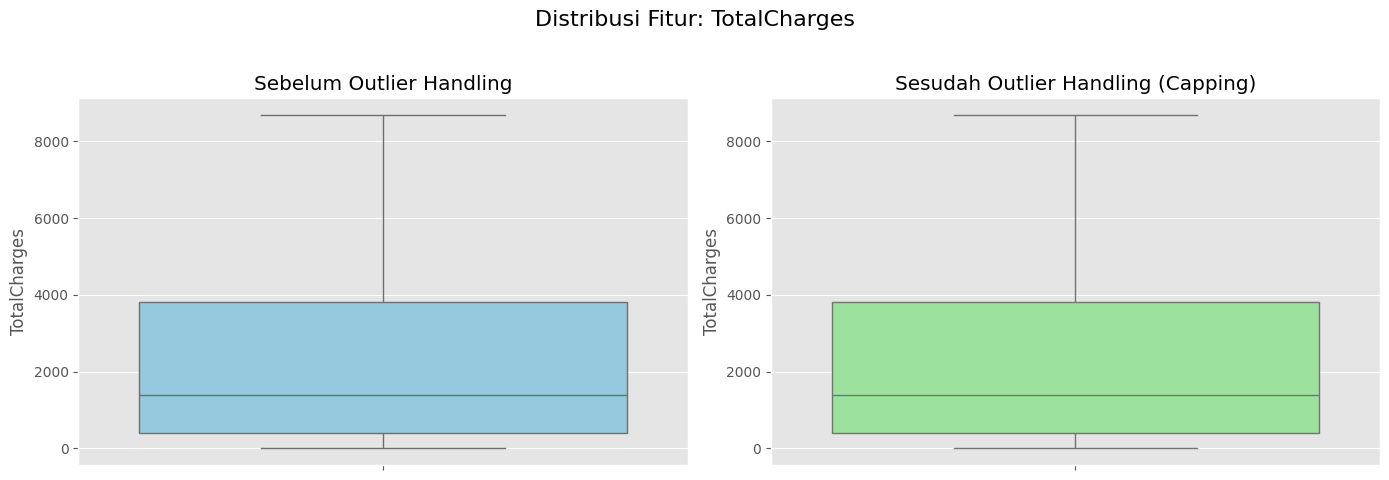


Membuat Plot Fitur Kategorikal...


/home/spark-24ee92a9-dc15-400b-aee1-f1/.ipykernel/3709/command-4895809287053424-2156531437:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/home/spark-24ee92a9-dc15-400b-aee1-f1/.ipykernel/3709/command-4895809287053424-2156531437:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/home/spark-24ee92a9-dc15-400b-aee1-f1/.ipykernel/3709/command-4895809287053424-2156531437:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/home/spark-24ee92a9-dc15-400b-aee1-f1/.ipykernel/3709/command-4895809287053424-2156531437:82: FutureWarning: 

Passing `

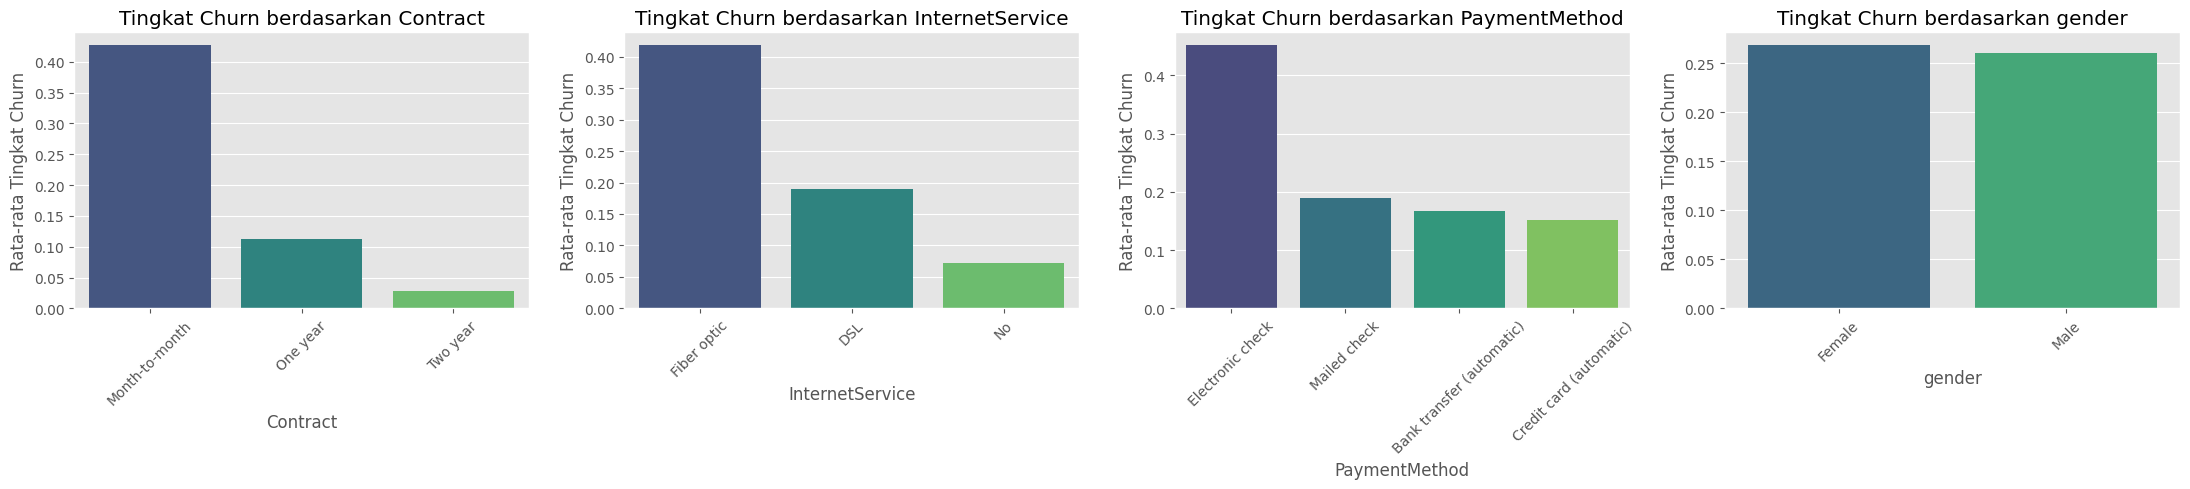

In [0]:
plt.style.use('ggplot')

numeric_features_for_eda = ["tenure", "MonthlyCharges", "TotalCharges"]

# HEATMAP KORELASI ANTAR FITUR NUMERIK
numeric_cols_for_corr = numeric_features_for_eda + ['Churn']
corr_matrix = df[numeric_cols_for_corr].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(
    corr_matrix, 
    annot=True,     
    cmap='coolwarm',
    fmt='.2f',      
    linewidths=0.5
)
plt.title('Heatmap Korelasi Fitur Numerik vs Churn')
plt.show()

# BOXPLOTS SEBELUM DAN SESUDAH OUTLIER HANDLING (IQR)
df_eda_outlier = df.copy()

# Tentukan fitur numerik yang akan diperiksa outlier
features_with_potential_outliers = [col for col in numeric_features_for_eda if col in df_eda_outlier.columns]

# Loop melalui setiap fitur dan tampilkan boxplot
for feature in features_with_potential_outliers:
    if df_eda_outlier[feature].dtype in ['int64', 'float64', 'int32', 'float32']:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle(f'Distribusi Fitur: {feature}', fontsize=16)

        # Boxplot Sebelum Outlier Handling
        sns.boxplot(y=df_eda_outlier[feature], ax=axes[0], color='skyblue')
        axes[0].set_title('Sebelum Outlier Handling')
        axes[0].set_ylabel(feature)

        # Hitung IQR untuk outlier handling
        Q1 = df_eda_outlier[feature].quantile(0.25)
        Q3 = df_eda_outlier[feature].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Terapkan capping: ganti outlier dengan batas atas/bawah
        df_eda_outlier[feature] = np.where(
            df_eda_outlier[feature] < lower_bound,
            lower_bound,
            df_eda_outlier[feature]
        )
        df_eda_outlier[feature] = np.where(
            df_eda_outlier[feature] > upper_bound,
            upper_bound,
            df_eda_outlier[feature]
        )
        
        # Boxplot Sesudah Outlier Handling (Capping)
        sns.boxplot(y=df_eda_outlier[feature], ax=axes[1], color='lightgreen')
        axes[1].set_title('Sesudah Outlier Handling (Capping)')
        axes[1].set_ylabel(feature)
        
        plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 
        plt.show()
    else:
        print(f"Peringatan: Kolom '{feature}' bukan tipe numerik dan dilewati untuk boxplot outlier.")

# ANALISIS FITUR KATEGORIKAL vs CHURN 
key_categorical_features = ['Contract', 'InternetService', 'PaymentMethod', 'gender'] 
plt.figure(figsize=(22, 5))

for i, col in enumerate(key_categorical_features):
    churn_rate = df.groupby(col)['Churn'].mean().reset_index().sort_values(by='Churn', ascending=False)
    
    plt.subplot(1, 4, i + 1)
    sns.barplot(
        x=col, 
        y='Churn', 
        data=churn_rate,
        palette='viridis'
    )
    plt.title(f'Tingkat Churn berdasarkan {col}')
    plt.ylabel('Rata-rata Tingkat Churn')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Persiapan Data (Preprocessing)

In [0]:
# Pisahkan fitur (X) dan target (y)
X = df.drop(["Churn"], axis=1, errors='ignore')
y = df["Churn"]

# Identifikasi kolom numerik dan kategorikal
all_numeric_features = ["tenure", "MonthlyCharges", "TotalCharges"]
all_categorical_features = [
    "gender", "Partner", "Dependents", "PhoneService", "MultipleLines", 
    "InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection", 
    "TechSupport", "StreamingTV", "StreamingMovies", "Contract", 
    "PaperlessBilling", "PaymentMethod","SeniorCitizen"
]

# Filter daftar fitur, buang kolom yang mungkin sudah di-drop
available_cols = X.columns
numeric_features = [col for col in all_numeric_features if col in available_cols]
categorical_features = [col for col in all_categorical_features if col in available_cols]

# Pipeline untuk data numerik pake median
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Pipeline untuk data kategorikal:
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Gabungkan kedua pipeline dengan ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder='passthrough'
)

Pipeline preprocessing berhasil dibuat.


Pelatihan, Evaluasi, dan Logging Model

In [0]:
# Pisahkan data training dan data testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Data latih: {len(X_train)} baris")
print(f"Data tes: {len(X_test)} baris")
print("-" * 30)

# Mulai MLflow Run
with mlflow.start_run(run_name="Model Klasifikasi Churn V4 (No-ID)") as run:
    
    # Buat pipeline model lengkap: Preprocessing + Model
    model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(random_state=42, max_iter=1000))
    ])
    
    # Latih model
    model.fit(X_train, y_train)
    
    # Lakukan prediksi
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    # 1. EVALUASI: CLASSIFICATION REPORT
    print("\n--- Classification Report ---")
    report_text = classification_report(y_test, y_pred)
    print(report_text)
    report_dict = classification_report(y_test, y_pred, output_dict=True)
    mlflow.log_dict(report_dict, "classification_report.json")

    # 2. EVALUASI: PLOT CONFUSION MATRIX
    fig_cm, ax_cm = plt.subplots()
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, ax=ax_cm, cmap=plt.cm.Blues)
    ax_cm.set_title("Confusion Matrix")
    mlflow.log_figure(fig_cm, "confusion_matrix.png")
    print("Confusion matrix berhasil di-log.")

    # 3. EVALUASI: PLOT ROC-AUC CURVE
    fig_roc, ax_roc = plt.subplots()
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax_roc)
    ax_roc.set_title("ROC-AUC Curve")
    mlflow.log_figure(fig_roc, "roc_auc_curve.png")
    print("ROC-AUC curve berhasil di-log.")
    
    # Tutup semua plot agar tidak tampil inline di notebook
    plt.close('all')

    # 4. LOGGING MODEL DENGAN SIGNATURE
    signature = infer_signature(X_train, model.predict(X_train))
    mlflow.sklearn.log_model(
        sk_model=model,
        artifact_path="model",
        signature=signature
    )
    print("Model berhasil di-log dengan signature.")

    # 5. CETAK METRIK UTAMA
    accuracy = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_proba)
    
    print("\n--- Metrik Utama ---")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"AUC: {auc:.4f}")
    print(f"\nRun ID: {run.info.run_id}")
    print("Eksperimen selesai. Cek MLflow UI untuk melihat artifact (plot).")

Data latih: 5616 baris
Data tes: 1405 baris
------------------------------
Memulai pelatihan model...
Pelatihan model selesai.

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.85      0.88      0.86      1053
           1       0.60      0.55      0.57       352

    accuracy                           0.79      1405
   macro avg       0.73      0.71      0.72      1405
weighted avg       0.79      0.79      0.79      1405

Confusion matrix berhasil di-log.
ROC-AUC curve berhasil di-log.


/databricks/python/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


Model berhasil di-log dengan signature.

--- Metrik Utama ---
Accuracy: 0.7943
AUC: 0.8461

Run ID: bda7f771aa5c489481abd970da65346d
Eksperimen selesai. Cek MLflow UI untuk melihat artifact (plot).
